In [1]:
!pip install -q kagglehub spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import spacy
from spacy import displacy
from spacy.matcher import Matcher
from collections import Counter

In [3]:
# carrega o dataset de notícias (json com um registro por linha)
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rmisra/news-category-dataset", "News_Category_Dataset_v3.json", pandas_kwargs={"lines": True})
print(df.shape)
df.head()

100%|██████████| 26.5M/26.5M [00:00<00:00, 93.3MB/s]

Extracting zip of News_Category_Dataset_v3.json...


(209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [4]:
# escolho 5 categorias e pego 2000 notícias de cada para ficar balanceado
categorias = ["POLITICS", "SPORTS", "TECH", "TRAVEL", "FOOD & DRINK"]
df = df[df["category"].isin(categorias)]
df = df.groupby("category").sample(n=2000, random_state=42).reset_index(drop=True)

# junta a manchete com a descrição curta
df["texto"] = df["headline"].fillna("") + ". " + df["short_description"].fillna("")
print(df["category"].value_counts())

category
FOOD & DRINK    2000
POLITICS        2000
SPORTS          2000
TECH            2000
TRAVEL          2000
Name: count, dtype: int64


## Parte – spaCy

In [5]:
nlp = spacy.load("en_core_web_sm")
# pega uma notícia de esporte para testar
doc = nlp(df[df["category"] == "SPORTS"]["texto"].iloc[0])
print(doc)

for token in doc[:12]:
    # texto, forma base, classe gramatical e função na frase
    print(token.text, token.lemma_, token.pos_, token.dep_)

For Some Gay Athletes At The Olympics, Being Out Is A Weight Lifted. Team USA's Gus Kenworthy and Canada's Eric Radford speak to HuffPost about their winning outlooks.
For for ADP prep
Some some DET det
Gay Gay PROPN compound
Athletes Athletes PROPN pobj
At at ADP prep
The the DET det
Olympics Olympics PROPN pobj
, , PUNCT punct
Being be AUX csubj
Out out ADV acomp
Is be AUX ROOT
A a DET det


In [6]:
# entidades que o modelo já reconhece
for ent in doc.ents:
    print(ent.text, ent.label_)
displacy.render(doc, style="ent", jupyter=True)

Olympics EVENT
Team USA's ORG
Gus Kenworthy PERSON
Canada GPE
Eric Radford PERSON
HuffPost PRODUCT


In [7]:
# roda o modelo em 200 notícias de cada categoria e conta os tipos de entidade
amostra = df.groupby("category").sample(n=200, random_state=42)
docs = list(nlp.pipe(amostra["texto"]))  # nlp.pipe processa em lote, mais rápido que um for

print(Counter(ent.label_ for d in docs for ent in d.ents).most_common(10))

[('ORG', 715), ('PERSON', 667), ('GPE', 383), ('DATE', 339), ('CARDINAL', 256), ('NORP', 131), ('WORK_OF_ART', 58), ('LOC', 53), ('ORDINAL', 42), ('EVENT', 40)]


In [8]:
frase = "The NBA Finals were streamed on Netflix and YouTube while Democrats criticized the GOP."
print([(ent.text, ent.label_) for ent in nlp(frase).ents])  # antes do ruler

[('NBA', 'ORG'), ('Netflix', 'GPE'), ('YouTube', 'GPE'), ('Democrats', 'NORP'), ('GOP', 'ORG')]


In [9]:
termos = {
    "SPORTS_ORG": ["NBA", "NFL", "MLB", "NHL", "FIFA", "Super Bowl", "World Cup", "NBA Finals", "Olympics", "Wimbledon"],
    "TECH_COMPANY": ["Apple", "Google", "Facebook", "Microsoft", "Amazon", "Twitter", "Tesla", "Netflix", "Uber", "YouTube"],
    "PARTY": ["Democrats", "Republicans", "GOP", "Democratic Party", "Republican Party"],
}

patterns = []
for label, lista in termos.items():
    for termo in lista:
        patterns.append({"label": label, "pattern": termo})  # cada termo vira uma regra com o seu rótulo

ruler = nlp.add_pipe("entity_ruler", before="ner")  # antes do ner para as regras terem prioridade
ruler.add_patterns(patterns)

print([(ent.text, ent.label_) for ent in nlp(frase).ents])  # depois do ruler

[('NBA Finals', 'SPORTS_ORG'), ('Netflix', 'TECH_COMPANY'), ('YouTube', 'TECH_COMPANY'), ('Democrats', 'PARTY'), ('GOP', 'PARTY')]


In [10]:
# em quais categorias os rótulos novos aparecem
docs = list(nlp.pipe(amostra["texto"]))
linhas = [(cat, ent.label_) for d, cat in zip(docs, amostra["category"]) for ent in d.ents if ent.label_ in termos]
df_ents = pd.DataFrame(linhas, columns=["category", "label"])
pd.crosstab(df_ents["label"], df_ents["category"])

category,FOOD & DRINK,POLITICS,SPORTS,TECH,TRAVEL
label,,,,,
PARTY,0,39,0,0,0
SPORTS_ORG,1,0,66,0,3
TECH_COMPANY,3,3,1,145,1


In [11]:
matcher = Matcher(nlp.vocab)

# manchete que começa com número: "10 Best Beaches", "5 Easy Recipes"
padrao_lista = [{"LIKE_NUM": True, "IS_SENT_START": True}, {"IS_ALPHA": True, "OP": "+"}]
# nome próprio + verbo de fala: "Bernie Sanders Says", "Trump Slams"
padrao_fala = [{"POS": "PROPN", "OP": "+"}, {"LOWER": {"IN": ["says", "slams", "calls", "warns", "claims"]}}]

matcher.add("LISTA", [padrao_lista], greedy="LONGEST")
matcher.add("FALA", [padrao_fala], greedy="LONGEST")

achados = []
for d, cat in zip(docs, amostra["category"]):
    for match_id, start, end in matcher(d):
        achados.append((nlp.vocab.strings[match_id], cat, d[start:end].text))
df_matches = pd.DataFrame(achados, columns=["padrao", "category", "texto"])

print(df_matches.groupby("padrao").head(4))  # alguns exemplos de cada padrão
pd.crosstab(df_matches["padrao"], df_matches["category"])  # quantos por categoria

   padrao      category                                              texto
0   LISTA  FOOD & DRINK           10 Free Restaurant Apps You Need to Have
1   LISTA  FOOD & DRINK                        9 Disgusting Things You Did
2   LISTA  FOOD & DRINK  One of the benefits of eating in restaurants i...
3   LISTA  FOOD & DRINK  7 Reasons Maple Syrup Is Good for Something Ot...
22   FALA      POLITICS                            Progressive Group Calls
24   FALA      POLITICS                                       Customs says
26   FALA      POLITICS                          Former Trump Adviser Says
28   FALA      POLITICS                              Tucker Carlson Claims


category,FOOD & DRINK,POLITICS,SPORTS,TECH,TRAVEL
padrao,,,,,
FALA,0,16,5,3,2
LISTA,22,5,9,12,30


## Parte – TensorFlow: classificar a categoria da notícia

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [15]:
vocab_size = 10000
max_length = 50

df = df.sample(frac=1, random_state=42)  # embaralha
sentences = df["texto"].tolist()
labels = df["category"].map({cat: i for i, cat in enumerate(categorias)}).values  # categoria vira número

training_size = 8000  # 80% treino e 20% teste
training_sentences, testing_sentences = sentences[:training_size], sentences[training_size:]
training_labels, testing_labels = labels[:training_size], labels[training_size:]

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)  # aprende o vocabulário só com o treino

training_padded = pad_sequences(tokenizer.texts_to_sequences(training_sentences), maxlen=max_length, padding="post", truncating="post")
testing_padded = pad_sequences(tokenizer.texts_to_sequences(testing_sentences), maxlen=max_length, padding="post", truncating="post")
print(training_padded.shape, testing_padded.shape)

(8000, 50) (2000, 50)


In [16]:
# mesmo modelo da aula do sarcasmo, mas com 5 saídas (uma por categoria)
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dense(5, activation="softmax"),  # softmax porque são 5 classes
])
# sparse porque os labels são números de 0 a 4
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(training_padded, training_labels, epochs=10,
                    validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/10
250/250 - 3s - 11ms/step - accuracy: 0.3219 - loss: 1.5588 - val_accuracy: 0.4460 - val_loss: 1.4741
Epoch 2/10
250/250 - 2s - 7ms/step - accuracy: 0.5288 - loss: 1.3284 - val_accuracy: 0.5900 - val_loss: 1.1589
Epoch 3/10
250/250 - 1s - 5ms/step - accuracy: 0.7128 - loss: 0.9477 - val_accuracy: 0.7390 - val_loss: 0.8556
Epoch 4/10
250/250 - 1s - 5ms/step - accuracy: 0.8449 - loss: 0.6600 - val_accuracy: 0.8095 - val_loss: 0.6678
Epoch 5/10
250/250 - 2s - 9ms/step - accuracy: 0.8929 - loss: 0.4752 - val_accuracy: 0.8365 - val_loss: 0.5660
Epoch 6/10
250/250 - 2s - 9ms/step - accuracy: 0.9220 - loss: 0.3553 - val_accuracy: 0.8535 - val_loss: 0.5064
Epoch 7/10
250/250 - 1s - 5ms/step - accuracy: 0.9416 - loss: 0.2708 - val_accuracy: 0.8540 - val_loss: 0.4658
Epoch 8/10
250/250 - 1s - 5ms/step - accuracy: 0.9574 - loss: 0.2122 - val_accuracy: 0.8625 - val_loss: 0.4456
Epoch 9/10
250/250 - 1s - 5ms/step - accuracy: 0.9649 - loss: 0.1686 - val_accuracy: 0.8650 - val_loss: 0.4334


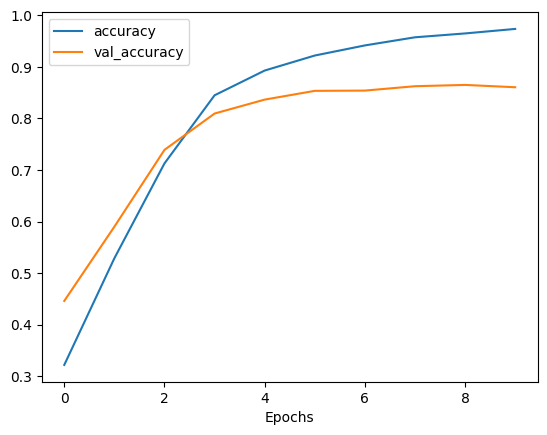

In [17]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epochs")
plt.legend(["accuracy", "val_accuracy"])
plt.show()

In [18]:
# testando com manchetes novas
novas = ["Lakers beat Celtics in overtime of the NBA Finals",
         "Apple launches a new iPhone with artificial intelligence",
         "10 hidden beaches in Portugal you need to visit"]

pred = model.predict(pad_sequences(tokenizer.texts_to_sequences(novas), maxlen=max_length, padding="post"))
for frase, p in zip(novas, pred):
    print(frase, "->", categorias[np.argmax(p)], f"({p.max():.0%})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Lakers beat Celtics in overtime of the NBA Finals -> SPORTS (94%)
Apple launches a new iPhone with artificial intelligence -> TECH (100%)
10 hidden beaches in Portugal you need to visit -> TRAVEL (84%)
